## 1. Import Necessary Library

In [67]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
import lightgbm as lgm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection

In [2]:
credit_card_data = pd.read_csv("credit_card_clean.csv")

In [9]:
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding

In [4]:
credit_card_data.shape

(30000, 25)

In [5]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [6]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 4. Data Preparation

In [7]:
le = LabelEncoder()

In [10]:
credit_card_data["SEX"] = le.fit_transform(credit_card_data.SEX)

In [11]:
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data.EDUCATION)
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data.MARRIAGE)

In [12]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [14]:
del credit_card_data["ID"]

In [15]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 5. Module Building

In [19]:
X = credit_card_data.drop("DEFAULT",axis=1)
y = credit_card_data["DEFAULT"]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,shuffle=True,test_size=0.20,random_state=12,stratify=y)

In [90]:
ad_clasifier = AdaBoostClassifier(n_estimators=40)
gd_clasifier = GradientBoostingClassifier(n_estimators=40)
xgb_clasifier = XGBClassifier(n_estimators=40)
lgb_Clasifier = lgm.LGBMClassifier(n_estimators=40,subsample_for_bin = 3000,num_leaves =5) 

## 6. Module Training

In [28]:
%%time
ad_clasifier.fit(X_train,y_train)

CPU times: total: 4.59 s
Wall time: 4.72 s


,estimator,None
,n_estimators,40
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [29]:
%%time
gd_clasifier.fit(X_train,y_train)

CPU times: total: 11.8 s
Wall time: 12 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,40
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [86]:
%%time
xgb_clasifier.fit(X_train,y_train)

CPU times: total: 1.56 s
Wall time: 460 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [91]:
%%time
lgb_Clasifier.fit(X_train,y_train)

[LightGBM] [Warning] Using too small ``bin_construct_sample_cnt`` may encounter unexpected errors and poor accuracy.
[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3214
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 406 ms
Wall time: 215 ms


,boosting_type,'gbdt'
,num_leaves,5
,max_depth,-1
,learning_rate,0.1
,n_estimators,40
,subsample_for_bin,3000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Module Testing

In [33]:
y_predict_ad  = ad_clasifier.predict(X_test)
y_predict_gd  = gd_clasifier.predict(X_test)
y_predict_xgb = xgb_clasifier.predict(X_test)
y_predict_lgb = lgb_Clasifier.predict(X_test)

## 8. Module Evaluation

### Adaboost Algorithm

In [55]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_predict_ad),3))
print("precision        : ",round(precision_score(y_test,y_predict_ad),3))
print("Recall           : ",round(recall_score(y_test,y_predict_ad),3))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_predict_ad))

Accuracy Score   :  0.82
precision        :  0.698
Recall           :  0.329
Confusion Matrix : 
 [[4484  189]
 [ 891  436]]


### Gradient Boosting

In [57]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_predict_gd),3))
print("precision        : ",round(precision_score(y_test,y_predict_gd),3))
print("Recall           : ",round(recall_score(y_test,y_predict_gd),3))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_predict_gd))

Accuracy Score   :  0.825
precision        :  0.705
Recall           :  0.361
Confusion Matrix : 
 [[4473  200]
 [ 848  479]]


### Extreme Gradient Boosting 

In [59]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_predict_xgb),3))
print("precision        : ",round(precision_score(y_test,y_predict_xgb),3))
print("Recall           : ",round(recall_score(y_test,y_predict_xgb),3))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_predict_xgb))

Accuracy Score   :  0.819
precision        :  0.662
Recall           :  0.372
Confusion Matrix : 
 [[4421  252]
 [ 834  493]]


### Light Grediant Boosting

In [60]:
print("Accuracy Score   : ",round(accuracy_score(y_test,y_predict_xgb),3))
print("precision        : ",round(precision_score(y_test,y_predict_xgb),3))
print("Recall           : ",round(recall_score(y_test,y_predict_xgb),3))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_predict_xgb))

Accuracy Score   :  0.819
precision        :  0.662
Recall           :  0.372
Confusion Matrix : 
 [[4421  252]
 [ 834  493]]


## Feature Imporatance

### Adaboost

In [61]:
ad_clasifier.feature_importances_

array([0.04730765, 0.        , 0.        , 0.02106567, 0.        ,
       0.53471432, 0.00465179, 0.0532692 , 0.        , 0.01731067,
       0.04369039, 0.03139553, 0.        , 0.01625357, 0.        ,
       0.        , 0.        , 0.10904895, 0.04166163, 0.03754931,
       0.037924  , 0.00415731, 0.        ])

In [64]:
Feature_Imp = pd.DataFrame(data = {"Features" :X.columns,
                     "Ada_Boost":ad_clasifier.feature_importances_,
                     "GD_Booast":gd_clasifier.feature_importances_,
                     "XGB_Boost":xgb_clasifier.feature_importances_,
                     "LGB_Boost":lgb_Clasifier.feature_importances_})

In [65]:
Feature_Imp

,Features,Ada_Boost,GD_Booast,XGB_Boost,LGB_Boost
0,LIMIT_BAL,0.047308,0.026844,0.020928,111
1,SEX,0.000000,0.000970,0.013702,13
2,EDUCATION,0.000000,0.001013,0.014511,19
3,MARRIAGE,0.021066,0.003871,0.015335,24
4,AGE,0.000000,0.002905,0.013168,66
5,PAY_1,0.534714,0.681717,0.442001,54
6,PAY_2,0.004652,0.088629,0.142798,31
7,PAY_3,0.053269,0.034230,0.045467,33
8,PAY_4,0.000000,0.017493,0.038961,25
9,PAY_5,0.017311,0.016560,0.028618,25


In [69]:
Feature_Imp.sort_values(by = "Ada_Boost",ascending = False)

,Features,Ada_Boost,GD_Booast,XGB_Boost,LGB_Boost
5,PAY_1,0.534714,0.681717,0.442001,54
17,PAY_AMT1,0.109049,0.013991,0.018085,73
7,PAY_3,0.053269,0.034230,0.045467,33
0,LIMIT_BAL,0.047308,0.026844,0.020928,111
10,PAY_6,0.043690,0.018507,0.027136,46
18,PAY_AMT2,0.041662,0.017526,0.016205,71
20,PAY_AMT4,0.037924,0.003926,0.015464,52
19,PAY_AMT3,0.037549,0.024059,0.024346,70
11,BILL_AMT1,0.031396,0.024230,0.021306,138
3,MARRIAGE,0.021066,0.003871,0.015335,24


<Axes: xlabel='Ada_Boost', ylabel='Features'>

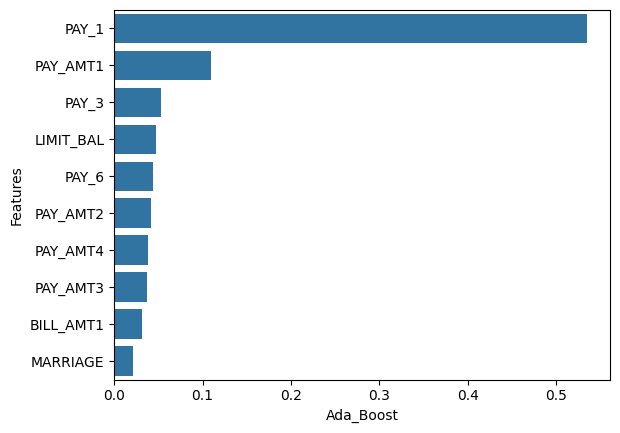

In [71]:
sns.barplot(data = Feature_Imp.sort_values(by = "Ada_Boost",ascending = False).head(10),x = "Ada_Boost",y = "Features")

<Axes: xlabel='GD_Booast', ylabel='Features'>

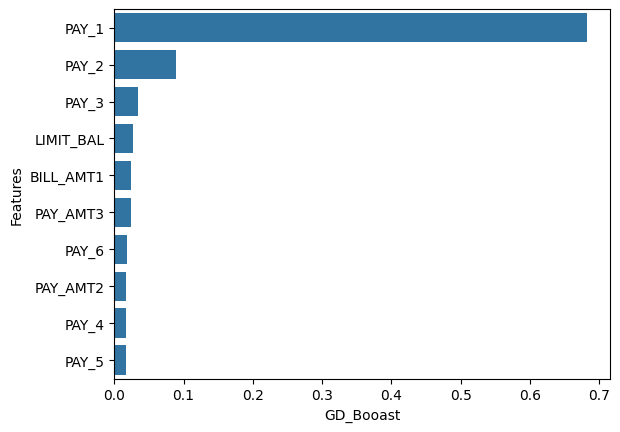

In [72]:
sns.barplot(data = Feature_Imp.sort_values(by = "GD_Booast",ascending = False).head(10),x = "GD_Booast",y = "Features")

<Axes: xlabel='XGB_Boost', ylabel='Features'>

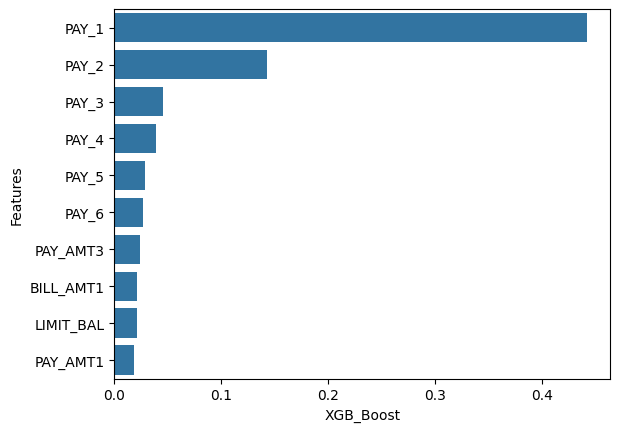

In [73]:
sns.barplot(data = Feature_Imp.sort_values(by = "XGB_Boost",ascending = False).head(10),x = "XGB_Boost",y = "Features")

<Axes: xlabel='LGB_Boost', ylabel='Features'>

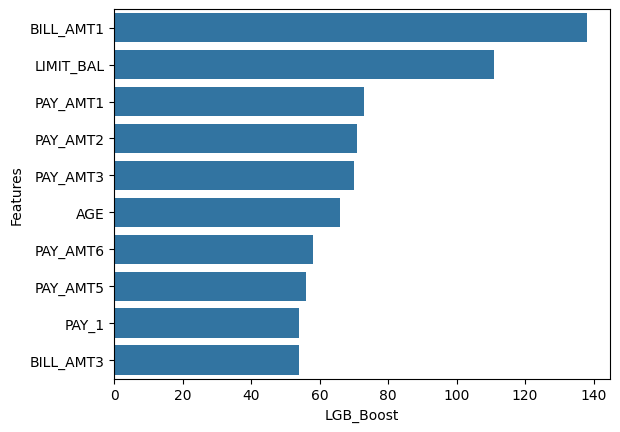

In [74]:
sns.barplot(data = Feature_Imp.sort_values(by = "LGB_Boost",ascending = False).head(10),x = "LGB_Boost",y = "Features")